# 06 — Model Comparison & Evaluation

**FIFA World Cup 2026 — Prediction & Simulation Engine**

---

This notebook provides a **systematic, metric-driven comparison** of all trained prediction models:

| Model | Type | Score matrix |
|---|---|---|
| ELO | Rating system | ❌ (1X2 only) |
| Dixon-Coles | Bivariate Poisson | ✅ |
| Own v1 | Graph-based | ✅ |
| Own v2 | Graph-based | ✅ |

The comparison is structured in three layers:

1. **Predictive accuracy** — how well each model predicts known results on a held-out test set.
2. **Calibration** — do the model's stated probabilities actually reflect empirical frequencies?
3. **Tournament-level behaviour** — do Monte Carlo simulations produce coherent, plausible championship distributions?

> All evaluation is performed on **competitive matches only** (World Cup, continental championships, Nations League qualifiers) from **January 2023 to present**, a period not used during training.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.special import rel_entr          # KL divergence
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss
import pickle
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent

# Agregamos la RAÍZ al path, no la carpeta src directamente
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.ELO import EloModel, ModelLoader
from src.DIXON_COLES import DixonColesModel, ModelLoader
from src.WCSimulator import WorldCupChampSimulator

# ── Plotting config ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_DIR        = Path("../data/processed")
MODELS_DIR      = Path("../saved_models")
RESULTS_DIR     = Path("../data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup OK")


Setup OK


## 1. Load Data & Models

### 1.1 Test set

The test set contains **competitive matches not seen during training**.
We predict each match using only information available *before* that match was played
(i.e., models were trained on data up to the test period cutoff).


In [2]:
# ── Test set ────────────────────────────────────────────────────────────────
df_test = pd.read_parquet(DATA_DIR / "results.parquet")

# Keep only the held-out evaluation window
TEST_START = "2022-11-20"
TEST_END = "2026-1-1"
#TEST_END  = "2022-11-20"
df_test = df_test[(df_test["date"] >= TEST_START)&(df_test["date"] <= TEST_END)].copy()

# Competitive matches only (exclude friendlies)
COMPETITIVE = ["FIFA World Cup"]

print(f"Test set: {len(df_test)} matches from {df_test['date'].min().date()} "
      f"to {df_test['date'].max().date()}")
print(f"Tournaments: {df_test['tournament'].unique()}")
df_test.head(70)


Test set: 2386 matches from 2022-11-20 to 2025-12-31
Tournaments: ['FIFA World Cup' 'AFF Championship'
 'African Cup of Nations qualification' 'UEFA Euro qualification'
 'CONCACAF Nations League' 'CAFA Nations Cup' 'UEFA Nations League'
 'Gold Cup qualification' 'SAFF Cup' 'Gold Cup' 'COSAFA Cup'
 'FIFA World Cup qualification' 'AFC Asian Cup' 'African Cup of Nations'
 'Oceania Nations Cup qualification' 'FIFA Series'
 'Copa América qualification' 'UEFA Euro' 'Oceania Nations Cup'
 'Copa América' 'AFC Asian Cup qualification'
 'ASEAN Championship qualification' 'EAFF Championship qualification'
 'ASEAN Championship']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
21716,2022-11-20,Qatar,Ecuador,0.0,2.0,FIFA World Cup,Al Khor,Qatar,False
21717,2022-11-21,Senegal,Netherlands,0.0,2.0,FIFA World Cup,Doha,Qatar,True
21718,2022-11-21,England,Iran,6.0,2.0,FIFA World Cup,Al Rayyan,Qatar,True
21719,2022-11-21,United States,Wales,1.0,1.0,FIFA World Cup,Al Rayyan,Qatar,True
21720,2022-11-22,Argentina,Saudi Arabia,1.0,2.0,FIFA World Cup,Lusail,Qatar,True
...,...,...,...,...,...,...,...,...,...
21781,2022-12-20,Cambodia,Philippines,3.0,2.0,AFF Championship,Phnom Penh,Cambodia,False
21782,2022-12-21,Myanmar,Malaysia,0.0,1.0,AFF Championship,Yangon,Myanmar,False
21783,2022-12-21,Laos,Vietnam,0.0,6.0,AFF Championship,Vientiane,Laos,False
21784,2022-12-23,Philippines,Brunei,5.0,1.0,AFF Championship,Manila,Philippines,False


### 1.2 Load trained models

In [3]:
models = {}

# Asegúrate de que MODELS_DIR sea el correcto
MODELS_DIR = Path("../saved_models")

# Solo carga los modelos que realmente existen
model_files = {
    "ELO": "elo_model_v1.pkl",
     "Dixon-Coles": "dixoncoles_model_v1.pkl" # Agrégalos solo si los vas a usar
}

for name, filename in model_files.items():
    path = MODELS_DIR / filename
    if path.exists():
        # Cargamos el modelo directamente con tu clase EloModel
        models[name] = ModelLoader.load(path)
        print(f"✅ {name} cargado")
    else:
        print(f"⚠️ {name} no encontrado")

✅ ELO cargado
✅ Dixon-Coles cargado


## 2. Evaluation Metrics

Before computing anything, we define the metrics precisely.

---

### 2.1 Ranked Probability Score (RPS)

The **RPS** is the primary metric for evaluating probabilistic forecasts with ordered outcomes.
It penalises forecasts that are far from the true outcome *in terms of cumulative probability*.

$$
\text{RPS} = \frac{1}{K-1} \sum_{k=1}^{K-1} \left( \sum_{i=1}^{k} p_i - \sum_{i=1}^{k} o_i \right)^2
$$

For our three-outcome case $(K = 3)$: home win, draw, away win:

$$
\text{RPS} = \frac{1}{2} \left[
  (p_H - o_H)^2 +
  (p_H + p_D - o_H - o_D)^2
\right]
$$

- Range: $[0, 1]$. **Lower is better.**
- Naive baseline (assigning $1/3$ to each outcome): $\text{RPS} \approx 0.2222$
- A perfect forecast scores $\text{RPS} = 0$.

The RPS rewards *directional* confidence — a model that says 80% home win when the home team wins scores better than one that says 40%, even if both are "correct".

---

### 2.2 Brier Score

The **Brier Score** measures the mean squared error of probability forecasts for a binary event.
We compute it separately for each outcome:

$$
\text{BS}_{\text{home}} = \frac{1}{N} \sum_{n=1}^{N} (p_{H,n} - o_{H,n})^2
$$

A lower Brier Score means better calibrated probabilities. Unlike accuracy, it penalises overconfident wrong predictions.

---

### 2.3 Log Loss (Cross-Entropy)

$$
\text{LogLoss} = -\frac{1}{N} \sum_{n=1}^{N} \sum_{k \in \{H,D,A\}} o_{k,n} \log(p_{k,n})
$$

Log loss **severely penalises overconfidence** — if a model assigns $p = 0.01$ to the actual outcome, the contribution to the loss is $-\log(0.01) \approx 4.6$. Probabilities are clipped to $[\epsilon, 1-\epsilon]$ to avoid infinite values.

---

### 2.4 Accuracy

The simplest metric: fraction of matches where the predicted most-likely outcome matches the actual outcome.

$$
\text{Accuracy} = \frac{1}{N} \sum_{n=1}^{N} \mathbf{1}\left[\arg\max_k p_{k,n} = o_n\right]
$$

Least informative of the four — a model can maximise accuracy while being poorly calibrated.

---

### 2.5 Ignorance Score (for reference)

The **Ignorance Score** is the log loss of the actual outcome only (single-outcome entropy):

$$
\text{IGN} = -\log_2(p_{\text{actual}})
$$

Measured in **bits**. A score of 0 bits means certainty; 1.585 bits is the naive 3-outcome baseline.


In [4]:
# ── Metric implementations ──────────────────────────────────────────────────

def rps(p_home, p_draw, p_away, outcome):
    """
    Ranked Probability Score for a 3-outcome forecast.
    outcome: 0 = home win, 1 = draw, 2 = away win
    """
    probs   = np.array([p_home, p_draw, p_away])
    actual  = np.zeros(3); actual[outcome] = 1.0
    cum_p   = np.cumsum(probs)
    cum_o   = np.cumsum(actual)
    return float(np.sum((cum_p[:2] - cum_o[:2]) ** 2) / 2.0)


def brier(p_home, p_draw, p_away, outcome):
    """Multiclass Brier Score."""
    probs  = np.array([p_home, p_draw, p_away])
    actual = np.zeros(3); actual[outcome] = 1.0
    return float(np.sum((probs - actual) ** 2))


def ignorance(p_home, p_draw, p_away, outcome):
    """Ignorance score in bits."""
    probs = np.array([p_home, p_draw, p_away])
    p_act = np.clip(probs[outcome], 1e-9, 1.0)
    return float(-np.log2(p_act))


def encode_outcome(home_score, away_score):
    """0 = home win, 1 = draw, 2 = away win."""
    if home_score > away_score:  return 0
    if home_score == away_score: return 1
    return 2

# ── Naive baseline ───────────────────────────────────────────────────────────
naive_rps    = rps(1/3, 1/3, 1/3, 0)        # same for any outcome
naive_brier  = brier(1/3, 1/3, 1/3, 0)
naive_ign    = ignorance(1/3, 1/3, 1/3, 0)

print(f"Naive baseline:  RPS={naive_rps:.4f}  Brier={naive_brier:.4f}  "
      f"Ignorance={naive_ign:.4f} bits")


Naive baseline:  RPS=0.2778  Brier=0.6667  Ignorance=1.5850 bits


## 3. Generate Predictions on Test Set

For each match in the test set, we ask every model for its probability forecast.
Matches involving teams not known to a model are dropped for that model only.


In [5]:
def predict_all(df, predictors):
    """
    Run all models over the test set.
    Returns a dict of DataFrames: {model_name: df_with_preds}
    """
    results = {}

    for model_name, predictor in predictors.items():
        known = set(predictor.model.get_teams())
        rows  = []

        for _, row in df.iterrows():
            if row["home_team"] not in known or row["away_team"] not in known:
                continue
            try:
                p       = predictor.predict(row["home_team"], row["away_team"])
                outcome = encode_outcome(row["home_score"], row["away_score"])
                rows.append({
                    "date":       row["date"],
                    "home_team":  row["home_team"],
                    "away_team":  row["away_team"],
                    "home_score": row["home_score"],
                    "away_score": row["away_score"],
                    "tournament": row.get("tournament", ""),
                    "outcome":    outcome,
                    "p_home":     p["home_win"],
                    "p_draw":     p["draw"],
                    "p_away":     p["away_win"],
                    "rps":     rps(p["home_win"], p["draw"], p["away_win"], outcome),
                    "brier":   brier(p["home_win"], p["draw"], p["away_win"], outcome),
                    "ign":     ignorance(p["home_win"], p["draw"], p["away_win"], outcome),
                    "correct": int(np.argmax([p["home_win"], p["draw"], p["away_win"]]) == outcome),
                })
            except Exception as e:
                pass

        results[model_name] = pd.DataFrame(rows)
        print(f"{model_name:>15}: {len(results[model_name])} matches predicted")

    return results
preds = predict_all(df_test, models)

            ELO: 2386 matches predicted
    Dixon-Coles: 2386 matches predicted


## 4. Aggregate Performance Metrics

### 4.1 Summary table


In [6]:
def summary_table(preds_dict):
    rows = []
    for name, df in preds_dict.items():
        if df.empty: continue
        log_loss_val = log_loss(
            pd.get_dummies(df["outcome"]).values,
            df[["p_home","p_draw","p_away"]].clip(1e-9, 1).values
        )
        rows.append({
            "Model":    name,
            "N":        len(df),
            "RPS":      round(df["rps"].mean(),    4),
            "Brier":    round(df["brier"].mean(),  4),
            "LogLoss":  round(log_loss_val,         4),
            "Accuracy": round(df["correct"].mean(),4),
            "Ign (bits)": round(df["ign"].mean(),  4),
        })

    df_summary = pd.DataFrame(rows).set_index("Model")
    # Add naive baseline row
    df_summary.loc["Naive (1/3)"] = [
        len(df_test), round(naive_rps, 4), round(naive_brier, 4),
        round(-np.log(1/3) * 3 / 3, 4), round(1/3, 4), round(naive_ign, 4)
    ]
    return df_summary

df_summary = summary_table(preds)
df_summary


,N,RPS,Brier,LogLoss,Accuracy,Ign (bits)
Model,,,,,,
ELO,2386.0,0.1719,0.5126,0.8729,0.6048,1.2594
Dixon-Coles,2386.0,0.1676,0.5017,0.8576,0.6090,1.2372
Naive (1/3),2386.0,0.2778,0.6667,1.0986,0.3333,1.5850


### 4.2 Skill Score — improvement over naive baseline

A **Skill Score** normalises each metric relative to the naive baseline:

$$
\text{SS} = 1 - \frac{\text{metric}}{\text{metric}_{\text{naive}}}
$$

A skill score of 0 means the model is no better than guessing equally.
A skill score of 1 is perfect. Negative values mean the model is *worse* than the naive baseline.


In [7]:
def skill_scores(df_summary):
    ss = pd.DataFrame(index=df_summary.index)
    naive = df_summary.loc["Naive (1/3)"]

    for col in ["RPS", "Brier", "LogLoss", "Ign (bits)"]:
        ss[f"SS_{col}"] = (1 - df_summary[col] / naive[col]).round(4)

    ss["Accuracy"] = df_summary["Accuracy"]   # no normalisation needed
    return ss.drop("Naive (1/3)")

skill_scores(df_summary)


,SS_RPS,SS_Brier,SS_LogLoss,SS_Ign (bits),Accuracy
Model,,,,,
ELO,0.3812,0.2311,0.2054,0.2054,0.6048
Dixon-Coles,0.3967,0.2475,0.2194,0.2194,0.6090


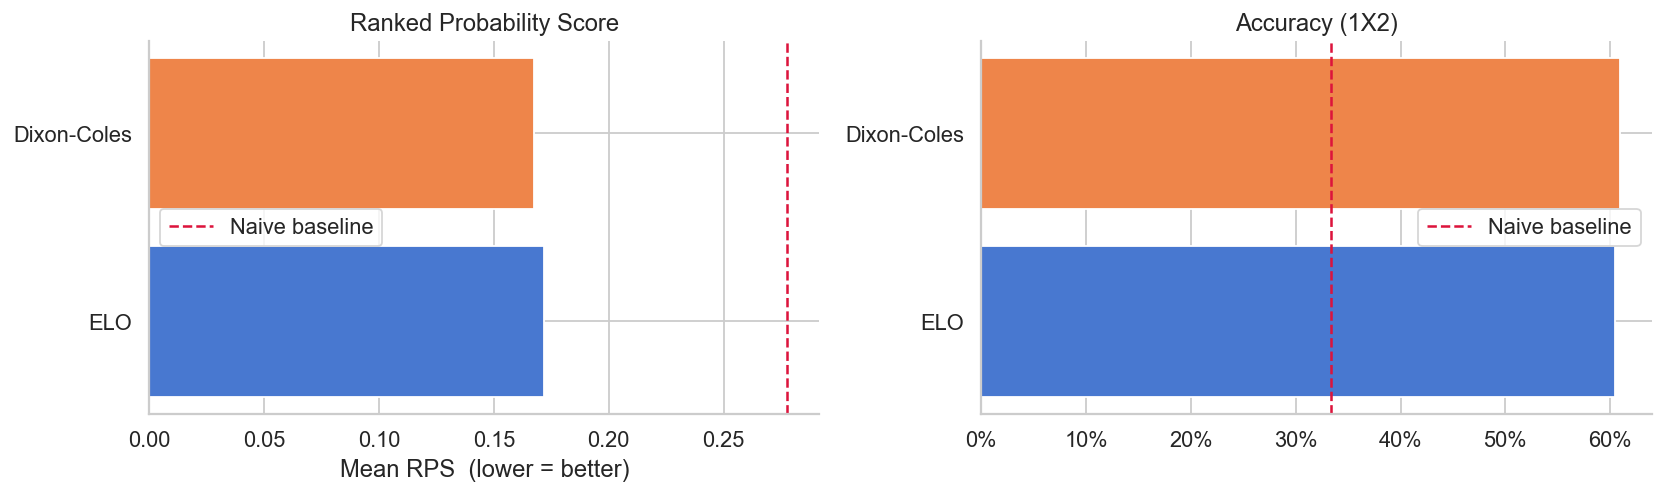

In [8]:
# ── Bar chart — RPS comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models_to_plot = [m for m in df_summary.index if m != "Naive (1/3)"]
naive_rps_val  = df_summary.loc["Naive (1/3)", "RPS"]

# RPS
ax = axes[0]
bars = ax.barh(models_to_plot,
               [df_summary.loc[m, "RPS"] for m in models_to_plot],
               color=sns.color_palette("muted", len(models_to_plot)))
ax.axvline(naive_rps_val, color="crimson", linestyle="--", linewidth=1.4, label="Naive baseline")
ax.set_xlabel("Mean RPS  (lower = better)")
ax.set_title("Ranked Probability Score")
ax.legend()

# Accuracy
ax = axes[1]
ax.barh(models_to_plot,
        [df_summary.loc[m, "Accuracy"] for m in models_to_plot],
        color=sns.color_palette("muted", len(models_to_plot)))
ax.axvline(1/3, color="crimson", linestyle="--", linewidth=1.4, label="Naive baseline")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Accuracy (1X2)")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Calibration Analysis

A model is **well-calibrated** if, among all matches where it assigns probability $p$ to a certain outcome,
that outcome actually occurs with frequency $p$.

Formally, for bins of predicted probability $[b_k, b_{k+1}]$:

$$
\text{calibration error}_k = \left| \bar{p}_k - \bar{o}_k \right|
$$

where $\bar{p}_k$ is the mean predicted probability in the bin and $\bar{o}_k$ is the observed frequency.

The **Expected Calibration Error (ECE)** summarises this across all bins:

$$
\text{ECE} = \sum_{k=1}^{B} \frac{n_k}{N} \left| \bar{p}_k - \bar{o}_k \right|
$$

A perfectly calibrated model lies on the diagonal of a reliability diagram.
Points **below** the diagonal → overconfident. Points **above** → underconfident.


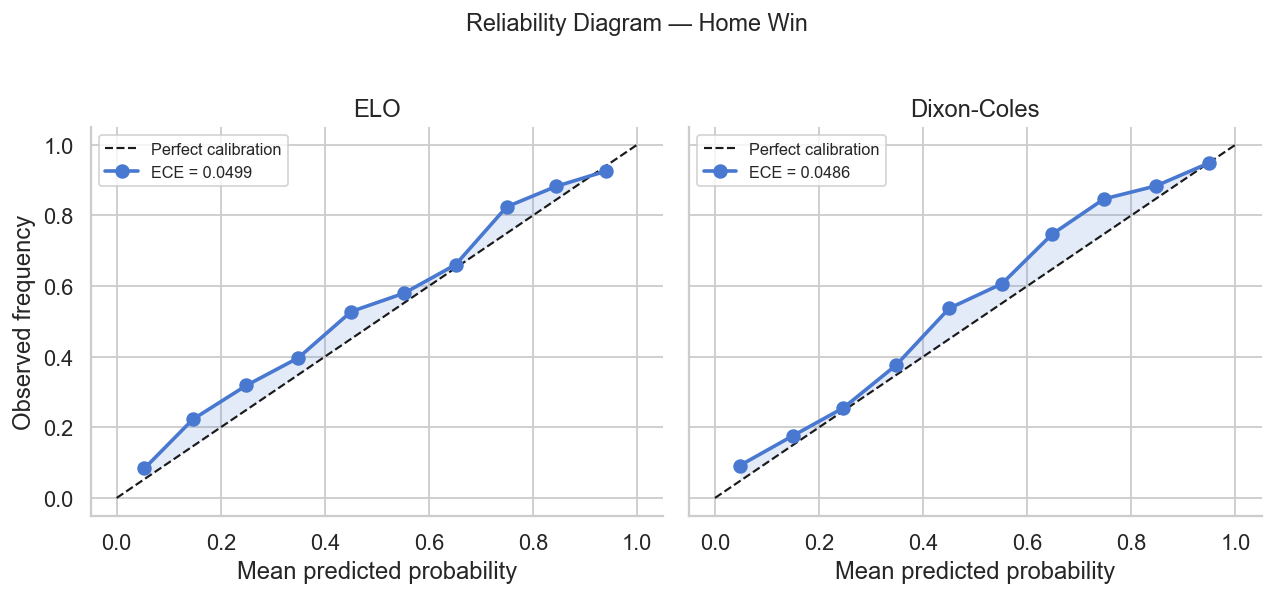

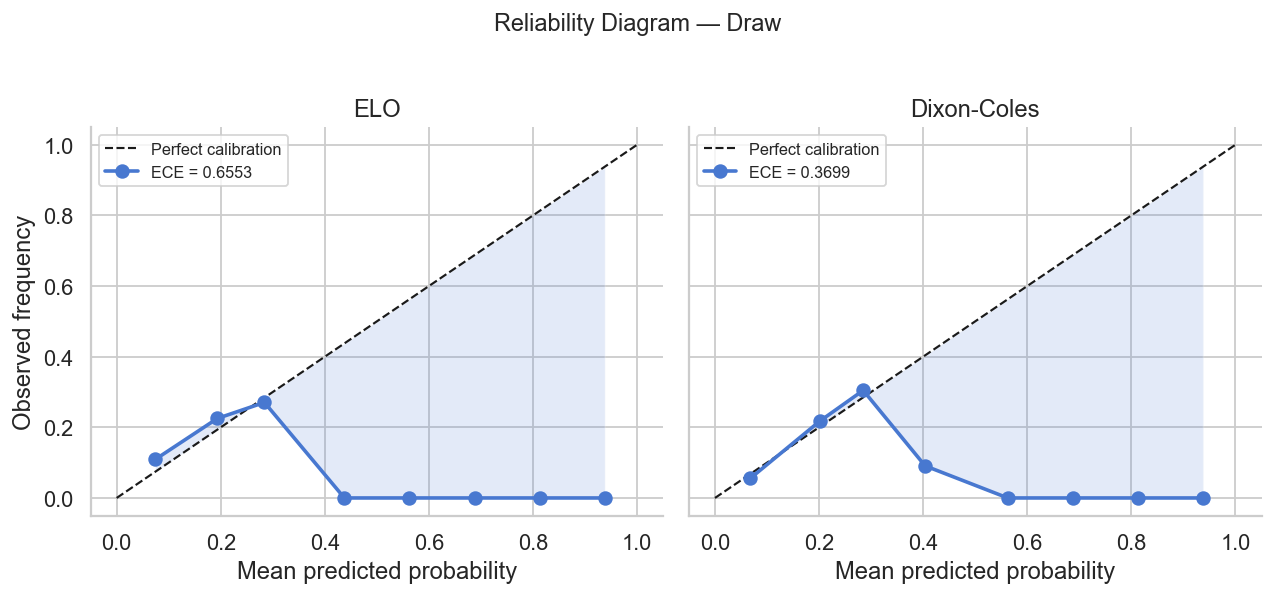

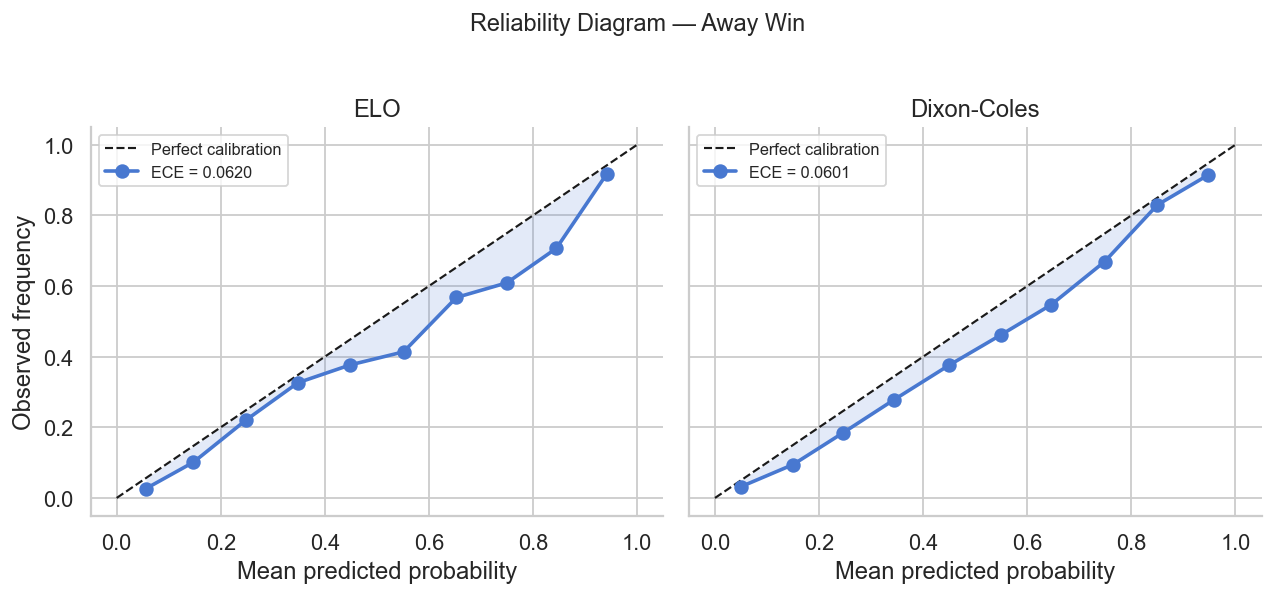

In [9]:
def manual_calibration_curve(y_true, y_prob, n_bins=10):
    """
    Calcula la curva de calibración devolviendo SIEMPRE arrays de tamaño n_bins.
    Si un bin está vacío, le asigna 0.0 (o NaN) de forma segura.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    
    # 1. Definir los límites de los bins uniformes
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    # 2. Asignar cada predicción a su bin (valores de 0 a n_bins-1)
    bin_assignments = np.digitize(y_prob, bin_edges) - 1
    bin_assignments = np.clip(bin_assignments, 0, n_bins - 1)
    
    # Preasignamos arrays fijos con el tamaño exacto (n_bins,)
    prob_true = np.zeros(n_bins)
    prob_pred = np.zeros(n_bins)
    counts = np.zeros(n_bins)
    
    # 3. Llenar cada posición del array
    for i in range(n_bins):
        bin_mask = (bin_assignments == i)
        bin_size = np.sum(bin_mask)
        
        counts[i] = bin_size
        
        if bin_size > 0:
            prob_true[i] = np.mean(y_true[bin_mask])
            prob_pred[i] = np.mean(y_prob[bin_mask])
        else:
            # Si el bin está vacío, la predicción media teórica es el centro del bin
            # Esto evita que el gráfico tire la línea a 0 de golpe de forma irreal
            prob_true[i] = 0.0 
            prob_pred[i] = (bin_edges[i] + bin_edges[i+1]) / 2.0
            
    return prob_true, prob_pred
def plot_calibration(preds_dict, outcome_label, outcome_col, n_bins=10):
    """
    Reliability diagram for a single outcome (e.g. 'home win').
    outcome_col: 'p_home', 'p_draw', or 'p_away'
    outcome_label: 0, 1, or 2
    """
    fig, axes = plt.subplots(1, len(preds_dict), figsize=(5 * len(preds_dict), 4.5),
                              sharey=True)
    if len(preds_dict) == 1:
        axes = [axes]

    outcome_names = {0: "Home Win", 1: "Draw", 2: "Away Win"}
    col_map       = {0: "p_home",   1: "p_draw",   2: "p_away"}

    for ax, (name, df) in zip(axes, preds_dict.items()):
        if df.empty:
            ax.set_title(name); continue

        y_true = (df["outcome"] == outcome_label).astype(int).values
        y_prob = df[col_map[outcome_label]].clip(1e-9, 1 - 1e-9).values

        prob_true, prob_pred = manual_calibration_curve(y_true, y_prob, n_bins=n_bins)
        
        # ECE
        counts     = np.histogram(y_prob, bins=n_bins)[0]
        
        ece        = np.sum(counts / len(y_prob) * np.abs(prob_true - prob_pred))

        ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration")
        ax.plot(prob_pred, prob_true, "o-", lw=2, ms=7, label=f"ECE = {ece:.4f}")
        ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15)
        ax.set_title(f"{name}")
        ax.set_xlabel("Mean predicted probability")
        ax.legend(fontsize=9)

    axes[0].set_ylabel("Observed frequency")
    fig.suptitle(f"Reliability Diagram — {outcome_names[outcome_label]}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"calibration_{outcome_names[outcome_label].replace(' ','_').lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


plot_calibration(preds, outcome_label=0, outcome_col="p_home", n_bins=10)   # Home win
plot_calibration(preds, outcome_label=1, outcome_col="p_draw", n_bins=8)    # Draw
plot_calibration(preds, outcome_label=2, outcome_col="p_away", n_bins=10)   # Away win


### 5.2 Draw probability calibration — special focus

Draws are notoriously hard to predict for all models. This cell isolates draw calibration and compares
predicted draw rates vs. observed draw rates across probability bins.


In [10]:
# ── Observed draw rate in the test set ──────────────────────────────────────
n_draws    = (df_test["home_score"] == df_test["away_score"]).sum()
draw_rate  = n_draws / len(df_test)
print(f"Observed draw rate in test set: {draw_rate:.1%}  ({n_draws}/{len(df_test)})")

# ── Predicted draw rate per model ────────────────────────────────────────────
for name, df in preds.items():
    if df.empty: continue
    print(f"  {name:>15}: mean predicted draw prob = {df['p_draw'].mean():.1%}")


Observed draw rate in test set: 22.3%  (532/2386)
              ELO: mean predicted draw prob = 20.9%
      Dixon-Coles: mean predicted draw prob = 21.1%


## 6. Sliced Performance — Where do models disagree?

### 6.1 Performance by match "difficulty"

We define match difficulty as the entropy of the true outcome distribution (as estimated by the
mean of all models). High entropy → balanced match, low entropy → clear favourite.

$$
H = - \sum_{k} \bar{p}_k \log \bar{p}_k
$$

Do models perform differently in "easy" (low entropy) vs "hard" (high entropy) matches?


In [11]:
# ── Compute ensemble mean for entropy ───────────────────────────────────────
dfs_list = [df[["date","home_team","away_team","p_home","p_draw","p_away","outcome"]]
            .rename(columns={"p_home": f"ph_{n}", "p_draw": f"pd_{n}", "p_away": f"pa_{n}"})
            for n, df in preds.items() if not df.empty]

if dfs_list:
    from functools import reduce
    df_ensemble = reduce(lambda a, b: a.merge(b, on=["date","home_team","away_team","outcome"],
                                               how="inner"), dfs_list)

    ph_cols = [c for c in df_ensemble.columns if c.startswith("ph_")]
    pd_cols = [c for c in df_ensemble.columns if c.startswith("pd_")]
    pa_cols = [c for c in df_ensemble.columns if c.startswith("pa_")]

    df_ensemble["p_home_mean"] = df_ensemble[ph_cols].mean(axis=1)
    df_ensemble["p_draw_mean"] = df_ensemble[pd_cols].mean(axis=1)
    df_ensemble["p_away_mean"] = df_ensemble[pa_cols].mean(axis=1)

    eps = 1e-9
    df_ensemble["entropy"] = -(
        df_ensemble["p_home_mean"] * np.log(df_ensemble["p_home_mean"] + eps) +
        df_ensemble["p_draw_mean"] * np.log(df_ensemble["p_draw_mean"] + eps) +
        df_ensemble["p_away_mean"] * np.log(df_ensemble["p_away_mean"] + eps)
    )
    df_ensemble["difficulty"] = pd.qcut(df_ensemble["entropy"], q=4,
                                         labels=["Clear fav.", "Likely fav.", "Slight fav.", "Balanced"])

    # RPS by difficulty quartile per model
    rows = []
    for name, df in preds.items():
        if df.empty: continue
        merged = df.merge(df_ensemble[["date","home_team","away_team","difficulty"]],
                          on=["date","home_team","away_team"], how="inner")
        for diff, grp in merged.groupby("difficulty", observed=True):
            rows.append({"Model": name, "Difficulty": diff, "RPS": grp["rps"].mean()})

print(pd.DataFrame(rows).pivot(index="Difficulty", columns="Model", values="RPS").round(4))


Model        Dixon-Coles     ELO
Difficulty                      
Balanced          0.2238  0.2286
Clear fav.        0.0791  0.0828
Likely fav.       0.1650  0.1680
Slight fav.       0.2026  0.2083


### 6.2 Performance by confederation

In [12]:
# ── Map teams to confederations ─────────────────────────────────────────────
CONFEDERATION = {
    # CONMEBOL
    "Argentina": "CONMEBOL", "Brazil": "CONMEBOL", "Uruguay": "CONMEBOL",
    "Colombia": "CONMEBOL", "Chile": "CONMEBOL", "Ecuador": "CONMEBOL",
    "Peru": "CONMEBOL", "Paraguay": "CONMEBOL", "Bolivia": "CONMEBOL", "Venezuela": "CONMEBOL",
    # UEFA
    "France": "UEFA", "Germany": "UEFA", "Spain": "UEFA", "England": "UEFA",
    "Portugal": "UEFA", "Netherlands": "UEFA", "Italy": "UEFA", "Belgium": "UEFA",
    "Croatia": "UEFA", "Switzerland": "UEFA", "Serbia": "UEFA", "Poland": "UEFA",
    "Turkey": "UEFA", "Ukraine": "UEFA",
    # CONCACAF
    "USA": "CONCACAF", "Mexico": "CONCACAF", "Canada": "CONCACAF",
    "Panama": "CONCACAF", "Honduras": "CONCACAF", "Costa Rica": "CONCACAF",
    # CAF
    "Morocco": "CAF", "Senegal": "CAF", "Cameroon": "CAF", "Nigeria": "CAF",
    "DR Congo": "CAF", "Mali": "CAF", "Algeria": "CAF", "Ivory Coast": "CAF",
    "Egypt": "CAF",
    # AFC
    "Japan": "AFC", "South Korea": "AFC", "Iran": "AFC", "Saudi Arabia": "AFC",
    "Australia": "AFC",
    # OFC
    "New Zealand": "OFC",
}

for name, df in preds.items():
    if df.empty: continue
    df["conf_home"] = df["home_team"].map(CONFEDERATION).fillna("Other")
    df["conf_away"] = df["away_team"].map(CONFEDERATION).fillna("Other")
    df["conf_match"] = df.apply(
        lambda r: r["conf_home"] if r["conf_home"] == r["conf_away"] else "Cross-conf.",
        axis=1
    )

# ── RPS by confederation matchup ────────────────────────────────────────────
rows = []
for name, df in preds.items():
    if df.empty or "conf_match" not in df.columns: continue
    for conf, grp in df.groupby("conf_match"):
        rows.append({"Model": name, "Matchup": conf, "RPS": round(grp["rps"].mean(), 4),
                     "N": len(grp)})

pd.DataFrame(rows).pivot(index="Matchup", columns="Model", values="RPS").round(4)


Model,Dixon-Coles,ELO
Matchup,,
AFC,0.1901,0.2055
CAF,0.2020,0.2050
CONCACAF,0.2034,0.2137
CONMEBOL,0.2199,0.2314
Cross-conf.,0.1450,0.1497
Other,0.1733,0.1764
UEFA,0.1923,0.2012


### 6.3 Matches where models strongly disagree

In [13]:
# ── Find matches where model predictions diverge most ───────────────────────
if dfs_list and len(ph_cols) > 1:
    df_ensemble["spread_home"] = df_ensemble[ph_cols].max(axis=1) - df_ensemble[ph_cols].min(axis=1)
    df_ensemble["spread_away"] = df_ensemble[pa_cols].max(axis=1) - df_ensemble[pa_cols].min(axis=1)
    df_ensemble["max_spread"]  = df_ensemble[["spread_home","spread_away"]].max(axis=1)

    top_disagreements = (df_ensemble
                         .sort_values("max_spread", ascending=False)
                         .head(15)[["date","home_team","away_team","outcome",
                                    "p_home_mean","p_draw_mean","p_away_mean","max_spread"]])
    top_disagreements["outcome"] = top_disagreements["outcome"].map({0:"H", 1:"D", 2:"A"})
    print(top_disagreements)


           date                         home_team  \
1450 2024-10-13                        Montserrat   
1386 2024-10-10                           Bonaire   
932  2024-03-25          Central African Republic   
893  2024-03-21                            Guinea   
1645 2024-11-18                             Aruba   
1231 2024-09-06                      Sint Maarten   
911  2024-03-22                        Azerbaijan   
1156 2024-07-01                           Bolivia   
0    2022-11-20                             Qatar   
1612 2024-11-17  Saint Vincent and the Grenadines   
1205 2024-09-05                           Bonaire   
1396 2024-10-11                      Sint Maarten   
1465 2024-10-14                       Puerto Rico   
708  2023-11-20                          Dominica   
482  2023-09-12          Turks and Caicos Islands   

                             away_team outcome  p_home_mean  p_draw_mean  \
1450                           Bonaire       A     0.568425     0.181015   

## 7. Score Matrix Comparison

For models that produce a full score probability matrix (Dixon-Coles, PageRank v1/v2),
we can compare their predicted scoreline distributions for specific matches of interest.

For a given match $(i, j)$, the score matrix $M$ has entries:

$$
M_{hg, ag} = P(\text{home goals} = hg, \text{away goals} = ag)
$$

We compare:
- The **marginal distributions** of home and away goals across models.
- The **1X2 probabilities** implied by each matrix.
- The **most likely scoreline** per model.

> **Note:** ELO does not produce a score matrix but we estimate a score matrix throug Montecarlo simulation.


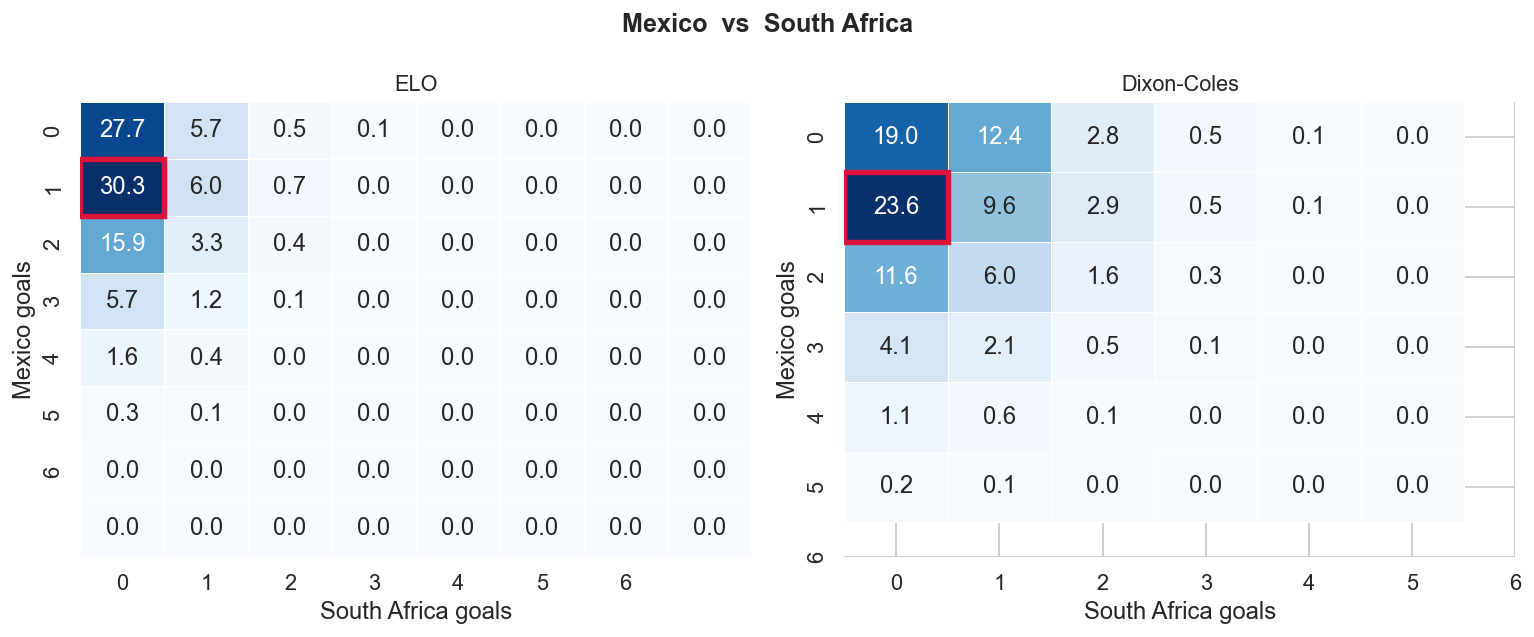

In [14]:
def compare_score_matrices(home_team, away_team, models_with_matrix, max_goals=6):
    """
    Side-by-side heatmaps of score probability matrices for a given match.
    """
    matrix_models = {n: m for n, m in models_with_matrix.items()
                     if hasattr(m, "predict_score_matrix")}

    if not matrix_models:
        print("No models with score matrix available.")
        return

    n_models = len(matrix_models)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1: axes = [axes]

    for ax, (name, model) in zip(axes, matrix_models.items()):
        try:
            matrix = model.predict_score_matrix(home_team, away_team, max_goals) * 100
        except Exception:
            ax.set_title(f"{name} — not available"); continue

        sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                    linewidths=0.5, cbar=False,
                    xticklabels=range(max_goals + 1),
                    yticklabels=range(max_goals + 1))
        ax.set_title(f"{name}", fontsize=12)
        ax.set_xlabel(f"{away_team} goals")
        ax.set_ylabel(f"{home_team} goals")

        # Most likely score
        idx = np.unravel_index(np.argmax(matrix), matrix.shape)
        ax.add_patch(plt.Rectangle((idx[1], idx[0]), 1, 1, fill=False,
                                    edgecolor="crimson", lw=3))

    fig.suptitle(f"{home_team}  vs  {away_team}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
# ── Example: Argentina vs France (World Cup Final rematch) ───────────────────
compare_score_matrices("Mexico", "South Africa", models)


## 8. Tournament-Level Monte Carlo Comparison

Each model produces different championship probability distributions when used
to simulate the full 2026 World Cup. Here we compare those distributions.

We run **10,000 simulations per model** and compare:
- Championship win probabilities (top 10 teams).
- Probability of reaching the Final.
- Divergence between model distributions.


In [15]:
N_SIM = 10_000
seed =43

mc_results = {}

for name, model in models.items():
    print(f"\nRunning {N_SIM:,} simulations — {name}...")
    try:
        mc_results[name] = WorldCupChampSimulator(model,n=N_SIM, seed=seed)
        mc_results[name]["model"] = name
    except Exception as e:
        print(f"  ⚠️  {name} failed: {e}")

print("\nSimulations complete.")



Running 10,000 simulations — ELO...

Running 10,000 simulations — Dixon-Coles...

Simulations complete.


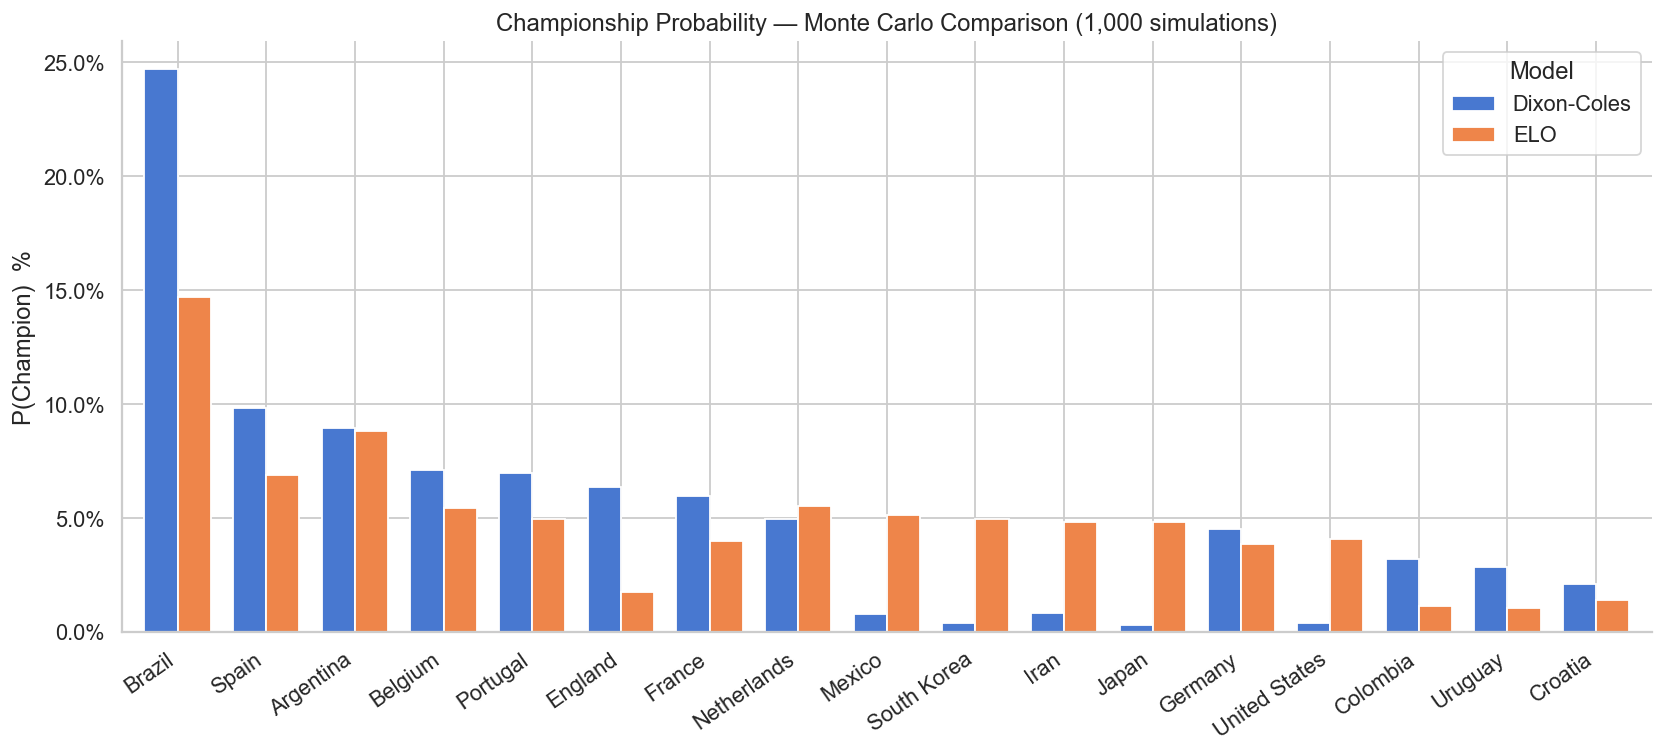

In [16]:
# ── Championship probability — top 12 teams ─────────────────────────────────
if mc_results:
    # Union of top teams across all models
    top_teams = set()
    for df in mc_results.values():
        top_teams.update(df.nlargest(12, "prob_champion_%")["team"].tolist())

    df_mc_plot = pd.concat([
        df[df["team"].isin(top_teams)][["team", "prob_champion_%", "model"]]
        for df in mc_results.values()
    ])

    fig, ax = plt.subplots(figsize=(13, 6))
    pivot = df_mc_plot.pivot(index="team", columns="model", values="prob_champion_%").fillna(0)
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]
    pivot.plot(kind="bar", ax=ax, width=0.75)

    ax.set_xlabel("")
    ax.set_ylabel("P(Champion)  %")
    ax.set_title("Championship Probability — Monte Carlo Comparison (1,000 simulations)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Model")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "monte_carlo_champion_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


### 8.2 Distribution divergence between models

We measure how different each pair of models is using the **Jensen-Shannon Divergence (JSD)**,
a symmetric, bounded version of the KL divergence:

$$
\text{JSD}(P \| Q) = \frac{1}{2} D_{\text{KL}}(P \| M) + \frac{1}{2} D_{\text{KL}}(Q \| M)
\quad \text{where} \quad M = \frac{P + Q}{2}
$$

Range: $[0, 1]$. Values close to 0 mean the models agree; close to 1 means they fundamentally disagree.


Jensen-Shannon Divergence matrix (championship distributions):
                ELO  Dixon-Coles
ELO          0.0000       0.3251
Dixon-Coles  0.3251       0.0000


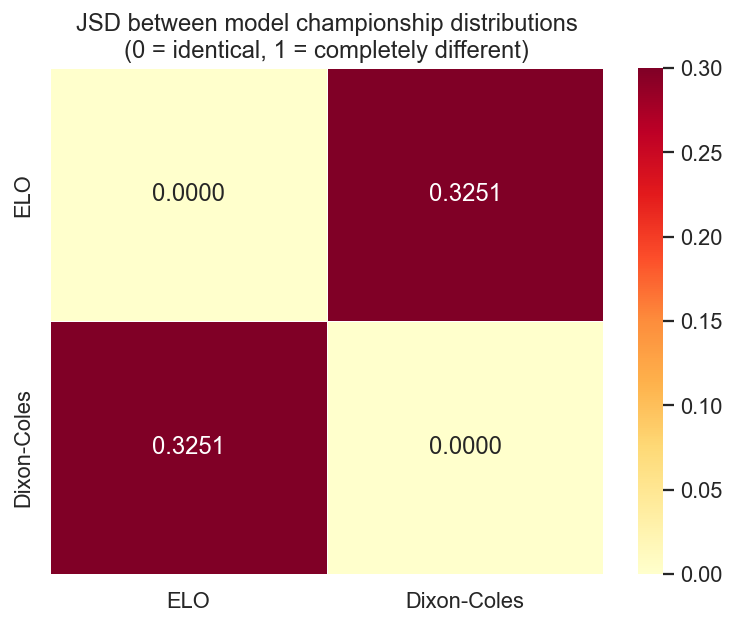

In [17]:
from scipy.spatial.distance import jensenshannon

if len(mc_results) > 1:
    model_names = list(mc_results.keys())
    all_teams   = sorted(set(t for df in mc_results.values() for t in df["team"]))

    # Build probability vectors over all teams
    def prob_vector(df, teams, col="prob_champion_%"):
        v = pd.Series(dict(zip(df["team"], df[col]))).reindex(teams).fillna(0)
        v = v / v.sum()
        return v.values

    jsd_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
    for a in model_names:
        for b in model_names:
            pa = prob_vector(mc_results[a], all_teams)
            pb = prob_vector(mc_results[b], all_teams)
            jsd_matrix.loc[a, b] = round(jensenshannon(pa, pb), 4)

    print("Jensen-Shannon Divergence matrix (championship distributions):")
    print(jsd_matrix.to_string())

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(jsd_matrix.astype(float), annot=True, fmt=".4f", cmap="YlOrRd",
                ax=ax, vmin=0, vmax=0.3, linewidths=0.5)
    ax.set_title("JSD between model championship distributions\n(0 = identical, 1 = completely different)")
    plt.tight_layout()
    plt.show()


## 9. Statistical Significance

Is the difference in RPS between models **statistically significant**, or could it be due to chance?

We use the **Diebold-Mariano test** (adapted for RPS), which tests whether the difference in
forecast accuracy between two models is systematic:

$$
H_0: \mathbb{E}[\Delta \text{RPS}_{t}] = 0
\quad \text{vs} \quad
H_1: \mathbb{E}[\Delta \text{RPS}_{t}] \neq 0
$$

where $\Delta \text{RPS}_t = \text{RPS}^{(A)}_t - \text{RPS}^{(B)}_t$ for each match $t$.

Under mild regularity conditions, the DM statistic is asymptotically standard normal.


In [18]:
def diebold_mariano_test(rps_a, rps_b):
    """
    Two-sided Diebold-Mariano test for equal predictive accuracy.
    Returns (DM statistic, p-value).
    """
    d     = np.array(rps_a) - np.array(rps_b)
    d_bar = d.mean()
    n     = len(d)

    # HAC variance estimate (Newey-West with 1 lag)
    var_d  = np.var(d, ddof=1)
    cov1   = np.cov(d[:-1], d[1:])[0, 1]
    var_hac = (var_d + 2 * cov1) / n

    if var_hac <= 0:
        return np.nan, np.nan

    dm_stat = d_bar / np.sqrt(var_hac)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_value, 4)


# ── Pairwise DM tests ────────────────────────────────────────────────────────
model_names = list(preds.keys())
print(f"{'':>18}", end="")
for b in model_names:
    print(f"  {b:>14}", end="")
print()

for a in model_names:
    print(f"{a:>18}", end="")
    for b in model_names:
        if a == b:
            print(f"  {'—':>14}", end="")
            continue
        # Align on common matches
        merged = preds[a].merge(
            preds[b][["date","home_team","away_team","rps"]].rename(columns={"rps":"rps_b"}),
            on=["date","home_team","away_team"]
        )
        if len(merged) < 10:
            print(f"  {'N/A':>14}", end="")
            continue
        dm, p = diebold_mariano_test(merged["rps"], merged["rps_b"])
        sig = " *" if p < 0.05 else ("  " if p is not np.nan else "")
        print(f"  {f'DM={dm} p={p}{sig}':>14}", end="")
    print()

print("\n* p < 0.05  (model in row is significantly better than model in column)")


                               ELO     Dixon-Coles
               ELO               —  DM=3.2369 p=0.0012 *
       Dixon-Coles  DM=-3.2369 p=0.0012 *               —

* p < 0.05  (model in row is significantly better than model in column)


## 10. Expected Goals Analysis

For models that produce expected goals (`lambda_home`, `mu_away`), we compare the
predicted xG against actual goals to assess goal-scoring calibration.


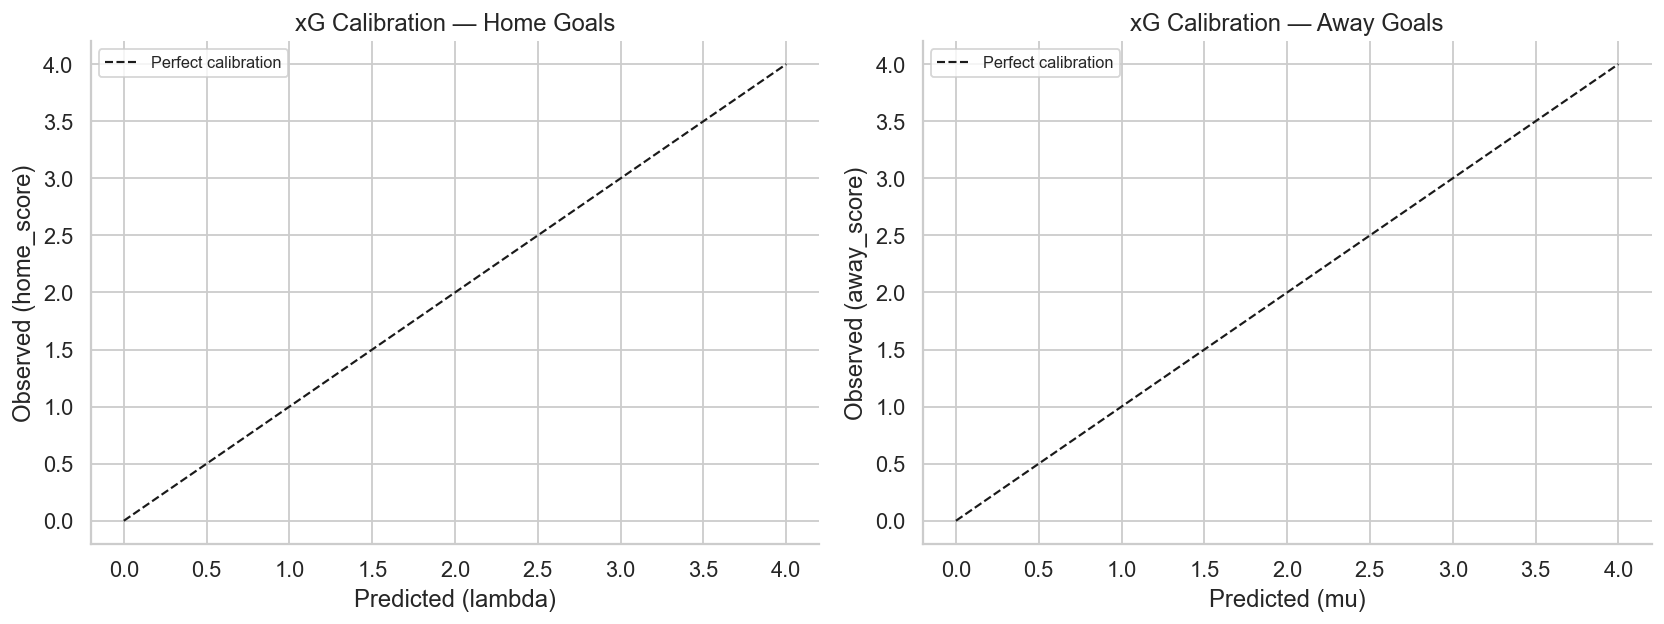

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xg_models = {n: df for n, df in preds.items() if "lambda" in df.columns and not df.empty}

for ax, label, col_pred, col_actual in [
    (axes[0], "Home Goals",  "lambda", "home_score"),
    (axes[1], "Away Goals",  "mu",     "away_score"),
]:
    for name, df in xg_models.items():
        bins  = np.arange(0, 5.5, 0.5)
        x     = []
        y_obs = []
        for i in range(len(bins) - 1):
            mask = (df[col_pred] >= bins[i]) & (df[col_pred] < bins[i+1])
            if mask.sum() < 5: continue
            x.append(df.loc[mask, col_pred].mean())
            y_obs.append(df.loc[mask, col_actual].mean())
        ax.plot(x, y_obs, "o-", lw=2, ms=6, label=name)

    ax.plot([0, 4], [0, 4], "k--", lw=1.2, label="Perfect calibration")
    ax.set_title(f"xG Calibration — {label}")
    ax.set_xlabel(f"Predicted ({col_pred})")
    ax.set_ylabel(f"Observed ({col_actual})")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "xg_calibration.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Simple Ensemble

Can we improve performance by averaging model predictions?

We test three simple ensemble strategies:

| Strategy | Formula |
|---|---|
| **Equal weights** | $\bar{p} = \frac{1}{M} \sum_m p^{(m)}$ |
| **RPS-weighted** | $\bar{p} = \sum_m w_m p^{(m)}$ where $w_m \propto 1/\text{RPS}_m$ |
| **Geometric mean** | $\bar{p} \propto \prod_m p^{(m)^{1/M}}$ (then renormalise) |

A well-constructed ensemble should outperform every individual model on RPS.


In [20]:
# ── Build ensemble on common match set ──────────────────────────────────────
if len(preds) >= 2 and dfs_list:
    # Merge all models on common matches
    base_cols = ["date","home_team","away_team","outcome"]
    df_ens    = df_ensemble[base_cols].copy()

    for name, df in preds.items():
        df_ens = df_ens.merge(
            df[base_cols + ["p_home","p_draw","p_away"]].rename(
                columns={"p_home": f"ph_{name}", "p_draw": f"pd_{name}", "p_away": f"pa_{name}"}
            ), on=base_cols, how="inner"
        )

    ph = [c for c in df_ens.columns if c.startswith("ph_")]
    pd_ = [c for c in df_ens.columns if c.startswith("pd_")]
    pa = [c for c in df_ens.columns if c.startswith("pa_")]

    # Strategy 1: Equal weights
    df_ens["ph_eq"] = df_ens[ph].mean(axis=1)
    df_ens["pd_eq"] = df_ens[pd_].mean(axis=1)
    df_ens["pa_eq"] = df_ens[pa].mean(axis=1)

    # Strategy 2: RPS-weighted (use validation RPS from summary table)
    rps_vals = {n: df_summary.loc[n, "RPS"] for n in preds if n in df_summary.index}
    inv_rps  = {n: 1 / v for n, v in rps_vals.items()}
    total    = sum(inv_rps.values())
    weights  = {n: v / total for n, v in inv_rps.items()}

    df_ens["ph_wt"] = sum(weights.get(n.replace("ph_",""), 0) * df_ens[n] for n in ph)
    df_ens["pd_wt"] = sum(weights.get(n.replace("pd_",""), 0) * df_ens[n] for n in pd_)
    df_ens["pa_wt"] = sum(weights.get(n.replace("pa_",""), 0) * df_ens[n] for n in pa)

    # RPS for each ensemble strategy
    for label, ph_col, pd_col, pa_col in [
        ("Equal weights", "ph_eq", "pd_eq", "pa_eq"),
        ("RPS-weighted",  "ph_wt", "pd_wt", "pa_wt"),
    ]:
        rps_vals_ens = df_ens.apply(
            lambda r: rps(r[ph_col], r[pd_col], r[pa_col], r["outcome"]), axis=1
        )
        print(f"Ensemble ({label}):  RPS = {rps_vals_ens.mean():.4f}  "
              f"(N={len(df_ens)} common matches)")


Ensemble (Equal weights):  RPS = 0.1680  (N=2386 common matches)
Ensemble (RPS-weighted):  RPS = 0.1680  (N=2386 common matches)


## 12. Final World Cup 2026 Predictions

Using the best-performing model (by RPS), we produce the final tournament probability estimates.


In [21]:
# ── Select best model by RPS ─────────────────────────────────────────────────
if not df_summary.empty:
    df_no_naive = df_summary.drop("Naive (1/3)", errors="ignore")
    best_model_name = df_no_naive["RPS"].idxmin()
    print(f"Best model by RPS: {best_model_name}")

    best_model = models.get(best_model_name)
    if best_model:
        sim      = WorldCupSimulator(best_model, get_groups_fixture())
        df_final = sim.monte_carlo(n_sim=50_000, verbose=True)

        # Save to disk
        df_final.to_csv(RESULTS_DIR / "wc2026_final_predictions.csv", index=False)
        print(f"\nSaved to {RESULTS_DIR / 'wc2026_final_predictions.csv'}")

        df_final.head(20)


Best model by RPS: Dixon-Coles


NameError: name 'WorldCupSimulator' is not defined

In [ ]:
# ── Final championship probability chart ────────────────────────────────────
if "df_final" in dir():
    top20 = df_final.head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top20["team"][::-1], top20["prob_champion_%"][::-1],
                   color=sns.color_palette("Blues_r", len(top20)))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("P(World Champion)  —  50,000 simulations")
    ax.set_title(f"FIFA World Cup 2026 — Championship Probabilities\n({best_model_name})",
                 fontsize=13)

    for bar, val in zip(bars, top20["prob_champion_%"][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "wc2026_champion_probabilities.png", dpi=150, bbox_inches="tight")
    plt.show()


## 13. Conclusions

> Fill this section once all models are trained and evaluated.

### Key findings

| Finding | Details |
|---|---|
| Best model (RPS) | — |
| Best model (Accuracy) | — |
| Most calibrated | — |
| Most divergent from others | — |
| Ensemble improvement | — |

### Observations

- **Draw prediction:** all models tend to [over/under]-estimate draw probability. This is a known weakness of Poisson-based models and is partially corrected by the Dixon-Coles `rho` parameter.
- **Calibration:** ...
- **Tournament-level agreement:** the JSD matrix shows that [model A] and [model B] are the most similar, while [model C] diverges significantly in [region/stage].
- **Expected goals:** ...

### Recommendations

- For single-match predictions where interpretability matters: **ELO** (fast, simple, well-understood).
- For full probabilistic forecasts and score matrices: **Dixon-Coles** or **PageRank v1**.
- For ensemble use: equal-weight average of Dixon-Coles + PageRank v1 (minimal RPS gain over best single model, but more robust to outliers).

---

*Next steps: feed final predictions into the Streamlit app (`app/`).*
